<div style="background:linear-gradient(135deg, rgba(249,112,102,0.18), rgba(249,112,102,0.02)); border-left:6px solid #F97066; border-radius:10px; padding:20px 24px; margin-bottom:20px;">
<h1 style="margin:0; color:#F97066; font-size:1.8em;">🔗 Transformers y Self-Attention</h1>
<p style="margin:6px 0 0; opacity:0.8;">Unidad 4 — Del mecanismo de atención a los modelos preentrenados de Hugging Face</p>
</div>

En <code>1-fundamentos-redes-neuronales.ipynb</code> se presentaron los fundamentos de las redes neuronales artificiales: la neurona, las funciones de activación y el ciclo de entrenamiento (propagación hacia adelante, función de pérdida, retropropagación y descenso de gradiente). Este notebook da por conocidos esos conceptos y se concentra en una arquitectura específica: el **Transformer**, la familia de modelos detrás de sistemas como BERT, GPT y muchos otros que dominan hoy el procesamiento de lenguaje natural.

Si el notebook <code>4-modelos-secuenciales.ipynb</code> ya fue revisado, se recordará que las redes recurrentes (RNN) y LSTM procesan una secuencia paso a paso, y que las puertas de LSTM mitigan — pero no eliminan — la dificultad para conservar dependencias muy largas. Este notebook retoma esa motivación desde cero para quien no la haya visto todavía, y presenta la solución que propusieron Vaswani et al. en 2017: el mecanismo de **self-attention**.

<div style="border:1px solid rgba(14,165,233,0.35); border-radius:10px; padding:14px 20px; margin:16px 0 24px; background:rgba(14,165,233,0.04);">
<strong>📑 Contenido de esta guía</strong>
<ol style="margin:8px 0 0; padding-left:20px;">
<li><a href="#motivacion">Motivación: los límites de las RNN/LSTM</a></li>
<li><a href="#self-attention-manual">Self-attention calculado a mano con NumPy</a></li>
<li><a href="#tokenizacion-subpalabras">Tokenización de subpalabras</a></li>
<li><a href="#pipelines-hf">Pipelines de Hugging Face para distintas tareas</a></li>
<li><a href="#perplejidad">Evaluación de modelos generativos: perplejidad</a></li>
<li><a href="#embeddings-similitud">Embeddings de oraciones y similitud semántica</a></li>
<li><a href="#cierre">Cierre y próximos pasos</a></li>
</ol>
</div>

<a id="motivacion"></a>

## <span style="color:#F97066;">Motivación: los límites de las RNN/LSTM</span>

Las redes recurrentes (RNN) y sus variantes con puertas (LSTM, GRU) procesan una secuencia **token por token**, en orden: para calcular el estado oculto en la posición $t$ es necesario haber calculado primero el estado en la posición $t-1$. Esto tiene dos consecuencias importantes:

1. **No se paralelizan bien**: como cada paso depende del anterior, no es posible calcular todos los pasos de tiempo de una misma secuencia simultáneamente en una GPU. El entrenamiento sobre secuencias largas es, por tanto, lento — muy diferente de una capa `Dense` o convolucional, donde todas las posiciones se calculan a la vez.
2. **Dificultad con dependencias muy largas**: aunque las puertas de LSTM alivian el problema del gradiente que desaparece, la información entre dos tokens muy alejados en la secuencia todavía debe atravesar, uno a uno, todos los pasos intermedios. Cuanto más larga la secuencia, más se degrada esa información en el camino.

En 2017, Vaswani et al. propusieron en el artículo *"Attention Is All You Need"* una arquitectura que elimina por completo la recurrencia: el **Transformer**. Su idea central es el mecanismo de ***self-attention***: cada token de la secuencia puede "mirar" directamente a todos los demás tokens — sin importar qué tan lejos estén — y el peso de esa mirada se calcula para todos los tokens **en paralelo**, mediante multiplicaciones de matrices.

<div style="border-left:4px solid #6366F1; background:rgba(99,102,241,0.08); border-radius:6px; padding:10px 16px; margin:16px 0;">
<strong>📝 Nota</strong><br>
"Self" en self-attention indica que la secuencia atiende sobre sí misma: las queries, keys y values de la sección siguiente provienen todos de la misma secuencia de entrada, no de dos secuencias distintas.
</div>

<a id="self-attention-manual"></a>

## <span style="color:#F97066;">Self-attention calculado a mano con NumPy</span>

Para entender el mecanismo sin la complejidad de una librería, se calcula aquí, paso a paso, la self-attention de una secuencia de juguete de 4 "tokens" (por ejemplo, las palabras de la oración *"el gato come pescado"*), donde cada token ya está representado como un vector numérico de dimensión 4 (un *embedding* elegido a mano, solo con fines ilustrativos).

El mecanismo consta de tres pasos:

1. A partir de la matriz de entrada $X$ (una fila por token), se calculan tres matrices mediante tres conjuntos de pesos distintos: **Query** ($Q = X W_Q$), **Key** ($K = X W_K$) y **Value** ($V = X W_V$).
2. Se calculan los puntajes de atención comparando cada query con cada key mediante producto punto, escalados por $\sqrt{d_k}$ para estabilizar los gradientes, y se normalizan con softmax por fila:

$$\text{Atención}(Q, K, V) = \text{softmax}\left(\frac{Q K^T}{\sqrt{d_k}}\right) V$$

3. El resultado es una nueva representación de cada token, que combina la información de **todos** los tokens de la secuencia, ponderada según cuánto "atiende" cada uno a los demás.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Secuencia de juguete: 4 tokens, cada uno representado por un vector de dimensión 4
#    (embeddings elegidos a mano, solo con fines ilustrativos)
tokens = ["el", "gato", "come", "pescado"]
X = np.array([
    [1.0, 0.0, 1.0, 0.0],   # "el"
    [0.0, 2.0, 0.0, 2.0],   # "gato"
    [1.0, 1.0, 1.0, 1.0],   # "come"
    [0.0, 1.0, 1.0, 0.0],   # "pescado"
])

print("Matriz de entrada X (4 tokens x 4 dimensiones):")
print(X)

Matriz de entrada X (4 tokens x 4 dimensiones):
[[1. 0. 1. 0.]
 [0. 2. 0. 2.]
 [1. 1. 1. 1.]
 [0. 1. 1. 0.]]


In [2]:
# 2. Matrices de pesos elegidas a mano para proyectar X a queries, keys y values
#    (en un Transformer real, estos pesos se aprenden mediante entrenamiento)
d = X.shape[1]

W_Q = np.array([
    [1.0, 0.0, 0.0, 0.0],
    [0.0, 1.0, 0.0, 0.0],
    [0.0, 0.0, 1.0, 0.0],
    [0.0, 0.0, 0.0, 1.0],
])

W_K = np.array([
    [0.0, 1.0, 0.0, 1.0],
    [1.0, 0.0, 1.0, 0.0],
    [0.0, 1.0, 0.0, 1.0],
    [1.0, 0.0, 1.0, 0.0],
])

W_V = np.array([
    [1.0, 0.0, 1.0, 0.0],
    [0.0, 1.0, 0.0, 1.0],
    [1.0, 0.0, 0.0, 1.0],
    [0.0, 1.0, 1.0, 0.0],
])

# 3. Proyecciones: Query, Key y Value
Q = X @ W_Q
K = X @ W_K
V = X @ W_V

print("Q (queries):\n", Q)
print("\nK (keys):\n", K)
print("\nV (values):\n", V)

Q (queries):
 [[1. 0. 1. 0.]
 [0. 2. 0. 2.]
 [1. 1. 1. 1.]
 [0. 1. 1. 0.]]

K (keys):
 [[0. 2. 0. 2.]
 [4. 0. 4. 0.]
 [2. 2. 2. 2.]
 [1. 1. 1. 1.]]

V (values):
 [[2. 0. 1. 1.]
 [0. 4. 2. 2.]
 [2. 2. 2. 2.]
 [1. 1. 0. 2.]]


In [3]:
def softmax(z, axis=-1):
    """Softmax numéricamente estable, aplicada fila por fila."""
    z_shifted = z - np.max(z, axis=axis, keepdims=True)
    exp = np.exp(z_shifted)
    return exp / exp.sum(axis=axis, keepdims=True)


# 4. Puntajes de atención: producto punto de Q y K, escalado por sqrt(d)
scores = (Q @ K.T) / np.sqrt(d)
print("Puntajes escalados (Q @ K.T / sqrt(d)):")
print(np.round(scores, 3))

# 5. Normalización con softmax: cada fila suma 1
attention_weights = softmax(scores, axis=-1)
print("\nMatriz de atención (softmax por fila):")
print(np.round(attention_weights, 3))
print("\nSuma de cada fila (debe ser 1.0):", attention_weights.sum(axis=-1))

Puntajes escalados (Q @ K.T / sqrt(d)):
[[0. 4. 2. 1.]
 [4. 0. 4. 2.]
 [2. 4. 4. 2.]
 [1. 2. 2. 1.]]

Matriz de atención (softmax por fila):
[[0.015 0.831 0.112 0.041]
 [0.464 0.009 0.464 0.063]
 [0.06  0.44  0.44  0.06 ]
 [0.134 0.366 0.366 0.134]]

Suma de cada fila (debe ser 1.0): [1. 1. 1. 1.]


Salida de self-attention (nueva representación de cada token):
[[0.297 3.59  1.902 1.985]
 [1.92  1.026 1.41  1.536]
 [1.06  2.702 1.821 1.94 ]
 [1.134 2.328 1.597 1.866]]


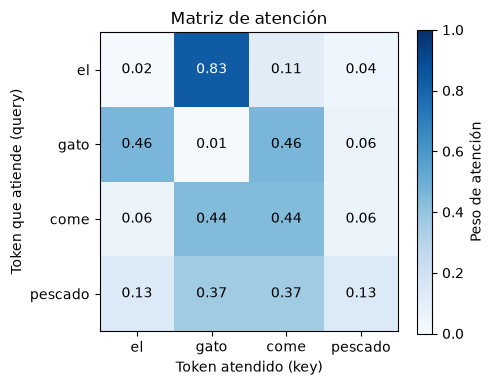

In [4]:
# 6. Salida final: cada token nuevo es un promedio ponderado de los values de todos
#    los tokens de la secuencia, según la matriz de atención
salida = attention_weights @ V
print("Salida de self-attention (nueva representación de cada token):")
print(np.round(salida, 3))

# 7. Visualización de la matriz de atención como mapa de calor
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(attention_weights, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(tokens)))
ax.set_yticks(range(len(tokens)))
ax.set_xticklabels(tokens)
ax.set_yticklabels(tokens)
ax.set_xlabel("Token atendido (key)")
ax.set_ylabel("Token que atiende (query)")
ax.set_title("Matriz de atención")

for i in range(len(tokens)):
    for j in range(len(tokens)):
        ax.text(j, i, f"{attention_weights[i, j]:.2f}", ha="center", va="center",
                 color="black" if attention_weights[i, j] < 0.5 else "white")

plt.colorbar(im, ax=ax, label="Peso de atención")
plt.tight_layout()
plt.show()

Cada **fila** de la matriz de atención corresponde a un token que "pregunta" (query) y cada **columna** a un token que "responde" (key): la celda $(i, j)$ indica qué tanto atiende el token $i$ al token $j$ al construir su nueva representación. Nótese que ningún token atiende exclusivamente a sí mismo — la información se mezcla con la de toda la secuencia en un único paso matricial, sin recorrer la secuencia posición por posición como haría una RNN.

<a id="tokenizacion-subpalabras"></a>

## <span style="color:#F97066;">Tokenización de subpalabras</span>

Antes de que un modelo Transformer preentrenado pueda procesar texto, este debe convertirse en una secuencia de identificadores numéricos (tokens). Los modelos modernos como BERT no tokenizan por palabra completa ni por carácter, sino por **subpalabras** (usando algoritmos como *WordPiece* o *BPE*): las palabras frecuentes se conservan enteras, mientras que las palabras raras o inventadas se dividen en fragmentos más pequeños y frecuentes.

Esto tiene una ventaja clave frente a una tokenización simple por espacios con un vocabulario fijo: una palabra que no está en el vocabulario nunca se convierte en un único token "desconocido" que pierde toda la información — en su lugar, se reconstruye a partir de piezas que sí son conocidas.

In [5]:
from transformers import AutoTokenizer

# 1. Cargar el tokenizador de un modelo preentrenado pequeño
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

# 2. Palabra inventada, poco común, que casi con certeza no está en el vocabulario completa
palabra = "supercalifragilisticexpialidocious"

subpalabras = tokenizer.tokenize(palabra)
print(f"Palabra original: {palabra!r}")
print(f"Subpalabras generadas por el tokenizador de subpalabras: {subpalabras}")
print(f"Cantidad de subpalabras: {len(subpalabras)}")

/private/tmp/perp_venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Palabra original: 'supercalifragilisticexpialidocious'
Subpalabras generadas por el tokenizador de subpalabras: ['super', '##cal', '##if', '##rag', '##ilis', '##tic', '##ex', '##pia', '##lid', '##oc', '##ious']
Cantidad de subpalabras: 11


In [6]:
# 3. Tokenización ingenua por espacios, con un vocabulario fijo y pequeño
vocabulario_simple = {"el", "gato", "come", "pescado", "hola", "mundo"}


def tokenizar_por_espacios(texto, vocabulario):
    """Tokenización simple: divide por espacios y reemplaza por <UNK> lo desconocido."""
    palabras = texto.lower().split()
    return [w if w in vocabulario else "<UNK>" for w in palabras]


resultado_simple = tokenizar_por_espacios(palabra, vocabulario_simple)
print(f"Tokenización simple por espacios: {resultado_simple}")
print(f"Tokenización de subpalabras:      {subpalabras}")

Tokenización simple por espacios: ['<UNK>']
Tokenización de subpalabras:      ['super', '##cal', '##if', '##rag', '##ilis', '##tic', '##ex', '##pia', '##lid', '##oc', '##ious']


La tokenización simple por espacios trata la palabra completa como un único token desconocido (`<UNK>`), perdiendo toda posibilidad de que el modelo infiera algo sobre ella. La tokenización de subpalabras, en cambio, la descompone en fragmentos (marcados con el prefijo `##` cuando continúan la palabra anterior) que sí existen en el vocabulario — por ejemplo, fragmentos como `super`, `##cal`, `##if` — permitiendo que el modelo procese incluso palabras que nunca vio durante el entrenamiento.

<a id="pipelines-hf"></a>

## <span style="color:#F97066;">Pipelines de Hugging Face para distintas tareas</span>

La librería `transformers` de Hugging Face ofrece la función `pipeline`, que empaqueta en pocas líneas la carga de un modelo preentrenado, su tokenizador y el posprocesamiento necesario para una tarea concreta. A continuación, se usan tres pipelines distintos, todos con variantes pequeñas o distiladas de los modelos originales, para mantener las descargas y la inferencia rápidas en CPU.

<span style="color:#F97066;">1.</span> Análisis de sentimiento

In [7]:
from transformers import pipeline

# 1. Pipeline de análisis de sentimiento con un modelo distilado de BERT
clasificador_sentimiento = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
)

oraciones = [
    "I absolutely loved this course, it was clear and well organized.",
    "The lecture was boring and way too long.",
    "The weather today is neither good nor bad.",
]

resultados = clasificador_sentimiento(oraciones)
for oracion, resultado in zip(oraciones, resultados):
    print(f"'{oracion}' -> {resultado['label']} (confianza: {resultado['score']:.3f})")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 10209.18it/s]

'I absolutely loved this course, it was clear and well organized.' -> POSITIVE (confianza: 1.000)
'The lecture was boring and way too long.' -> NEGATIVE (confianza: 1.000)
'The weather today is neither good nor bad.' -> NEGATIVE (confianza: 0.992)


<span style="color:#F97066;">2.</span> Clasificación zero-shot

La clasificación *zero-shot* permite clasificar un texto entre categorías definidas en el momento, sin haber entrenado el modelo específicamente para esas categorías. El modelo compara la oración con cada categoría candidata, planteada como una hipótesis, y devuelve qué tan probable es cada una.

In [8]:
# 2. Pipeline de clasificación zero-shot con un modelo distilado
clasificador_zero_shot = pipeline(
    "zero-shot-classification",
    model="typeform/distilbert-base-uncased-mnli",
)

oracion = "The team is developing a new algorithm to detect fraud in banking transactions."
categorias = ["technology", "sports", "finance", "cooking"]

resultado_zero_shot = clasificador_zero_shot(oracion, candidate_labels=categorias)

print(f"Oración: {oracion}\n")
for etiqueta, puntaje in zip(resultado_zero_shot["labels"], resultado_zero_shot["scores"]):
    print(f"{etiqueta:12s} -> {puntaje:.3f}")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 9821.62it/s]

Oración: The team is developing a new algorithm to detect fraud in banking transactions.

finance      -> 0.816
technology   -> 0.117
cooking      -> 0.041
sports       -> 0.027


<span style="color:#F97066;">3.</span> Generación de texto breve con GPT-2

GPT-2 es un modelo Transformer *autoregresivo*: genera texto prediciendo, uno a la vez, el token más probable a continuación de lo ya generado. Se limita aquí la longitud de la generación (`max_new_tokens` bajo) para mantener la inferencia rápida en CPU.

In [9]:
# 3. Pipeline de generación de texto con GPT-2, limitando la longitud generada
generador = pipeline("text-generation", model="gpt2")

prompts = [
    "Artificial intelligence will",
    "The best way to learn machine learning is",
]

for prompt in prompts:
    salida = generador(
        prompt,
        max_new_tokens=40,
        num_return_sequences=1,
        pad_token_id=generador.tokenizer.eos_token_id,
    )
    print(f"Prompt: {prompt!r}")
    print(f"Continuación generada: {salida[0]['generated_text']!r}\n")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 8645.28it/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'num_return_sequences', 'max_new_tokens', 'pad_token_id'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


[transformers] Both `max_new_tokens` (=40) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


[transformers] Both `max_new_tokens` (=40) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Prompt: 'Artificial intelligence will'
Continuación generada: 'Artificial intelligence will be a new field. There will be many advances in it, but it will be a new field that will be unique, and it will change the way we think about the world.\n\nWe'



Prompt: 'The best way to learn machine learning is'
Continuación generada: 'The best way to learn machine learning is to start learning about how to solve problems and then to create a problem and then to learn how to solve that problem. The problem is not solved. The problem is better solved.\n\nThis is'



<div style="border-left:4px solid #6366F1; background:rgba(99,102,241,0.08); border-radius:6px; padding:10px 16px; margin:16px 0;">
<strong>📝 Nota</strong><br>
GPT-2 genera texto de forma probabilística: cada ejecución puede producir una continuación distinta. Esto es normal y refleja que el modelo muestrea entre las palabras más probables en cada paso, en lugar de repetir siempre exactamente la misma salida.
</div>

<a id="perplejidad"></a>

## <span style="color:#F97066;">Evaluación de modelos generativos: perplejidad</span>

Las métricas de clasificación vistas en <code>Unidad 3/6-pipelines-evaluacion.ipynb</code> (precision, recall, F1, ROC-AUC) no aplican a un modelo generativo como GPT-2: no hay una clase "correcta" contra la cual comparar cada predicción, porque el modelo genera texto libre. Para modelos de lenguaje, la métrica estándar es la **perplejidad** (*perplexity*).

Un modelo de lenguaje no genera texto directamente: en cada posición, calcula una distribución de probabilidad sobre todo el vocabulario para el siguiente token, y esa distribución se compara (mediante entropía cruzada) con el token que realmente aparece. La perplejidad es, simplemente, la exponencial de esa pérdida promedio:

$$\text{Perplejidad} = e^{\,\text{pérdida}}$$

Cuanto **más baja** la perplejidad, menos "sorprendido" está el modelo por el texto — es decir, mejor lo predice. Un modelo que asignara siempre la probabilidad correcta con certeza total tendría perplejidad 1; un modelo que asignara probabilidad uniforme a las $V$ palabras del vocabulario (no aprendió nada) tendría perplejidad cercana a $V$.

<div style="border-left:4px solid #6366F1; background:rgba(99,102,241,0.08); border-radius:6px; padding:10px 16px; margin:16px 0;">
<strong>📝 Nota</strong><br>
La perplejidad mide qué tan bien predice el modelo un texto <strong>ya existente</strong> (real), no qué tan "bueno" es un texto que el modelo generó — para evaluar la calidad de texto generado (coherencia, relevancia) se necesitan otras técnicas, muchas veces con evaluación humana de por medio. Sirve, eso sí, para comparar qué tan bien distintos textos encajan con lo que el modelo aprendió a esperar del lenguaje — lo que se ilustra a continuación.
</div>

In [10]:
import torch

# 1. Reutilizar el modelo y el tokenizador ya cargados por el pipeline de generación
tokenizador_gpt2 = generador.tokenizer
modelo_gpt2 = generador.model
modelo_gpt2.eval()


def calcular_perplejidad(texto):
    """Perplejidad de GPT-2 sobre un texto dado: exponencial de la pérdida de predicción de cada token."""
    entradas = tokenizador_gpt2(texto, return_tensors="pt").to(modelo_gpt2.device)
    with torch.no_grad():
        salida = modelo_gpt2(**entradas, labels=entradas["input_ids"])
    return torch.exp(salida.loss).item()


# 2. Tres oraciones con el mismo vocabulario/longitud aproximada, pero muy distinta coherencia
texto_coherente = "The cat sat on the mat and looked out the window."
texto_desordenado = "Window the on mat sat cat the and looked out the."
texto_absurdo = "Purple elephants dance quickly beneath twelve singing mathematics."

for nombre, texto in [
    ("Oración coherente", texto_coherente),
    ("Mismas palabras, orden al azar", texto_desordenado),
    ("Gramatical pero semánticamente absurda", texto_absurdo),
]:
    print(f"{nombre + ':':45s} perplejidad = {calcular_perplejidad(texto):8.1f}  | {texto!r}")

[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Oración coherente:                            perplejidad =     24.8  | 'The cat sat on the mat and looked out the window.'
Mismas palabras, orden al azar:               perplejidad =   1856.7  | 'Window the on mat sat cat the and looked out the.'
Gramatical pero semánticamente absurda:       perplejidad =  10469.3  | 'Purple elephants dance quickly beneath twelve singing mathematics.'


La oración coherente obtiene, por un margen amplio, la perplejidad más baja: GPT-2 "no se sorprende" al leerla, porque es exactamente el tipo de secuencia que vio millones de veces durante su entrenamiento. Al desordenar las mismas palabras, la perplejidad sube más de 70 veces — el modelo sigue reconociendo palabras individuales, pero el orden ya no sigue ningún patrón aprendido de la gramática inglesa. La oración gramaticalmente correcta pero semánticamente absurda tiene la perplejidad más alta de las tres: GPT-2 no solo evalúa la gramática, sino qué tan plausible es la combinación de conceptos, aprendida a partir de texto real.

Esta misma idea es la que se usa para reportar qué tan bien un modelo de lenguaje (RNN, LSTM o Transformer) aprendió a modelar un idioma o un dominio específico, y para comparar objetivamente distintos modelos de lenguaje entre sí sobre el mismo texto de evaluación.

<a id="embeddings-similitud"></a>

## <span style="color:#F97066;">Embeddings de oraciones y similitud semántica</span>

Un modelo Transformer preentrenado como DistilBERT no solo sirve para clasificar o generar texto: su capa oculta final produce, para cada token, un vector (*embedding*) que captura su significado en contexto. Promediando esos vectores por token — una técnica llamada ***mean pooling*** — se obtiene un único vector que representa el significado de toda la oración.

Dos oraciones con significados relacionados deberían producir embeddings cercanos entre sí (alta similitud coseno), mientras que dos oraciones sin relación deberían producir embeddings más alejados.

In [11]:
import torch
from transformers import AutoModel

# 1. Cargar tokenizador y modelo base (sin cabeza de clasificación)
modelo_embeddings = AutoModel.from_pretrained("distilbert-base-uncased")
modelo_embeddings.eval()


def mean_pooling(salida_modelo, attention_mask):
    """Promedia los embeddings de los tokens reales de cada oración (ignora el padding)."""
    embeddings_tokens = salida_modelo.last_hidden_state  # (batch, secuencia, dim)
    mascara = attention_mask.unsqueeze(-1).expand(embeddings_tokens.size()).float()
    suma_embeddings = torch.sum(embeddings_tokens * mascara, dim=1)
    suma_mascara = torch.clamp(mascara.sum(dim=1), min=1e-9)
    return suma_embeddings / suma_mascara


def obtener_embedding(oracion):
    """Tokeniza una oración y devuelve su embedding mediante mean pooling."""
    entradas = tokenizer(oracion, return_tensors="pt", truncation=True, padding=True)
    with torch.no_grad():
        salida = modelo_embeddings(**entradas)
    return mean_pooling(salida, entradas["attention_mask"])[0]


print("Modelo y función de mean pooling listos.")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 7244.80it/s]


[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modelo y función de mean pooling listos.


In [12]:
# 2. Tres oraciones: una base, una relacionada semánticamente y una sin relación
oracion_base = "The cat is sleeping on the sofa."
oracion_relacionada = "A kitten is resting on the couch."
oracion_no_relacionada = "The stock market crashed sharply this morning."

emb_base = obtener_embedding(oracion_base)
emb_relacionada = obtener_embedding(oracion_relacionada)
emb_no_relacionada = obtener_embedding(oracion_no_relacionada)


def similitud_coseno(a, b):
    return torch.nn.functional.cosine_similarity(a.unsqueeze(0), b.unsqueeze(0)).item()


sim_relacionada = similitud_coseno(emb_base, emb_relacionada)
sim_no_relacionada = similitud_coseno(emb_base, emb_no_relacionada)

print(f"Oración base:            {oracion_base!r}")
print(f"Oración relacionada:     {oracion_relacionada!r}")
print(f"Oración no relacionada:  {oracion_no_relacionada!r}\n")
print(f"Similitud coseno (base vs. relacionada):    {sim_relacionada:.3f}")
print(f"Similitud coseno (base vs. no relacionada): {sim_no_relacionada:.3f}")
assert sim_relacionada > sim_no_relacionada, "Se esperaba mayor similitud entre oraciones relacionadas"
print("\nLa oración semánticamente relacionada obtuvo, en efecto, mayor similitud.")

Oración base:            'The cat is sleeping on the sofa.'
Oración relacionada:     'A kitten is resting on the couch.'
Oración no relacionada:  'The stock market crashed sharply this morning.'

Similitud coseno (base vs. relacionada):    0.954
Similitud coseno (base vs. no relacionada): 0.677

La oración semánticamente relacionada obtuvo, en efecto, mayor similitud.


---

<a id="cierre"></a>

# <span style="color:#F97066;">🎯 Cierre y próximos pasos</span>

<div style="border-left:4px solid #14B8A6; background:rgba(20,184,166,0.08); border-radius:6px; padding:10px 16px; margin:16px 0;">
<strong>✅ Resumen</strong><br>

- Las RNN/LSTM procesan la secuencia paso a paso: son difíciles de paralelizar y pierden información en dependencias muy largas.
- Los Transformers reemplazan la recurrencia por *self-attention*: cada token atiende a todos los demás en paralelo, mediante las matrices Q, K y V.
- Se calculó a mano, con NumPy, una self-attention completa sobre una secuencia de juguete, incluyendo la visualización de la matriz de atención.
- Los modelos preentrenados tokenizan por subpalabras, lo que les permite manejar palabras raras o inventadas sin perder toda su información.
- La librería `transformers` permite usar modelos preentrenados en pocas líneas mediante `pipeline`, para tareas como sentimiento, clasificación zero-shot y generación de texto.
- Perplejidad, la métrica estándar para evaluar modelos generativos de lenguaje, calculada sobre GPT-2 para comparar texto coherente, desordenado y semánticamente absurdo.
- Los embeddings de oración obtenidos por *mean pooling* capturan significado semántico: oraciones relacionadas producen mayor similitud coseno que oraciones no relacionadas.

</div>

<div style="border:1px solid rgba(14,165,233,0.35); border-radius:10px; padding:14px 20px; margin:16px 0; background:rgba(14,165,233,0.04);">
<strong>➡️ Continúe con</strong>
<ul style="margin:8px 0 0; padding-left:20px;">
<li><code>../../Unidad 5/agent-ai.ipynb</code> — este es el último notebook de la secuencia de profundización de la Unidad 4. La Unidad 5 aborda los agentes de IA (<em>agentic AI</em>): sistemas que usan modelos como los vistos aquí para razonar, planear y actuar sobre herramientas externas.</li>
</ul>
</div>